# Which Degrees Are Actually Oversupplied?

## The Question

Notebooks 01–07 treated "graduates" as one group. But independent reporting consistently says the mismatch is concentrated in specific fields, not spread evenly. Which fields actually carry the oversupply, and is it true that shortage fields exist side by side with it?

## The Answer

Yes, the field-level data is stark. Social sciences, business, and law account for the largest share of unemployed graduates by a wide margin, both in absolute numbers and as a share of that field's own graduates. Engineering, manufacturing, and construction (despite being popular targets for a "graduate oversupply" narrative) actually shows a *lower* unemployment share than social sciences/business/law. At the same time, 70% of *all* employed graduates nationally were in semi- or low-skilled roles in 2023, meaning the mismatch problem isn't confined to the highest-unemployment field alone, it's broader than any single field's headline number suggests.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
field = pd.read_csv('../data/processed/unemployed_graduates_by_field.csv')
field

,field,unemployed_count,unemployment_share_of_field_pct
0,"Social Sciences, Business & Law",14665,15.6
1,"Sciences, Mathematics & Computing",4113,12.8
2,"Engineering, Manufacturing & Construction",8950,11.4


In [2]:
# House chart style v2: consulting-exhibit conventions (MBB-style):
# gray for context series, one or two accent colors for what the title is
# actually about, direct end-of-line/bar labels instead of a legend box.
ACCENT_1 = '#2a78d6'   # primary accent, the series the title is about
ACCENT_2 = '#eb6834'   # secondary accent; used only for genuine two-way comparisons
                        # or a title that names two co-equal findings
GRAY = '#9a9a95'        # de-emphasized / context series, same family, faded out
INK, INK_SECONDARY, INK_MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE = '#ececea', '#fcfcfb'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'text.color': INK,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'axes.grid.axis': 'y',
    'grid.color': GRID,
    'grid.linewidth': 0.7,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'legend.frameon': False,
})

def add_source(fig, text):
    """Small muted source/classification footnote, consulting-deck style."""
    fig.text(0.01, -0.04, text, ha='left', va='top', fontsize=8.5,
              color=INK_MUTED, style='italic', transform=fig.transFigure)

def end_label(ax, x, y, text, color, weight='semibold', va='center', offset=8):
    """Direct label at a line's endpoint, replacing a legend box."""
    ax.annotate(text, xy=(x, y), xytext=(offset, 0), textcoords='offset points',
                 va=va, ha='left', fontsize=10.5, fontweight=weight, color=color)


## Unemployed graduates by field of study

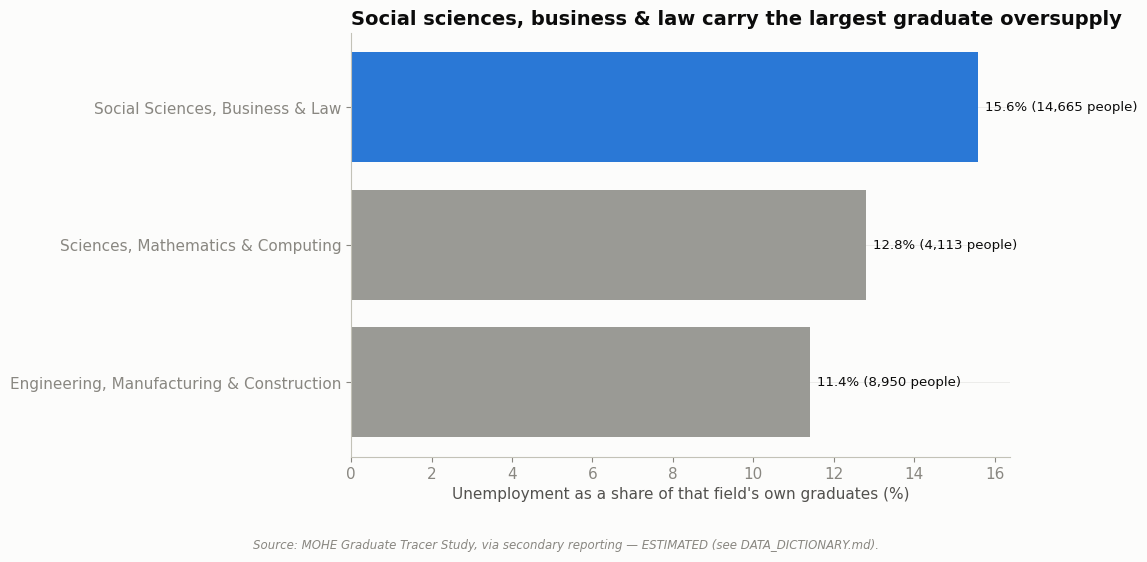

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
field_sorted = field.sort_values('unemployment_share_of_field_pct')
colors = [ACCENT_1 if v == field_sorted['unemployment_share_of_field_pct'].max() else GRAY
          for v in field_sorted['unemployment_share_of_field_pct']]
bars = ax.barh(field_sorted['field'], field_sorted['unemployment_share_of_field_pct'], color=colors)
for i, (b, n) in enumerate(zip(bars, field_sorted['unemployed_count'])):
    ax.annotate(f"{b.get_width():.1f}% ({n:,.0f} people)", xy=(b.get_width(), b.get_y()+b.get_height()/2),
                xytext=(5, 0), textcoords='offset points', va='center', fontsize=9.5)
ax.set_title('Social sciences, business & law carry the largest graduate oversupply', loc='left')
ax.set_xlabel("Unemployment as a share of that field's own graduates (%)")
add_source(ax.figure, 'Source: MOHE Graduate Tracer Study, via secondary reporting \u2014 ESTIMATED (see DATA_DICTIONARY.md).')
plt.show()

## Why Is This Happening? (Context)

*Qualitative, secondary-sourced context on the mechanism behind this notebook's finding; kept separate from the ESTIMATED figures above. Full citations in [`DATA_DICTIONARY.md`](../DATA_DICTIONARY.md).*

This pattern is consistent with what Malaysian labour-market researchers describe as a supply-side imbalance: universities have expanded enrolment fastest in relatively low-cost-to-deliver programmes (business, social sciences, general humanities) rather than the higher-cost, faculty-and-lab-intensive technical and industrial fields employers report shortages in. The result isn't "too many graduates" as a uniform national problem; it's a mismatch between where degree-granting capacity was built and where the economy's actual skilled-job demand sits, which is exactly why an engineering graduate and a social-science graduate face such different odds despite graduating in the same year from the same national system.

**Source:** [Human Resources Online, "Malaysia faces graduate oversupply, skilled job shortage, and a growing 'gaji cukup makan' reality"](https://www.humanresourcesonline.net/malaysia-faces-graduate-oversupply-skilled-job-shortage-and-a-growing-gaji-cukup-makan-reality).

## Strategic Recommendation

- **A prospective student weighing field of study should treat this as materially more decision-relevant than the overall "graduate unemployment rate" headline**, the gap between the highest- and lowest-risk fields charted above is far larger than the gap between graduates and non-graduates nationally (Notebook 01).
- **A business in a shortage field (engineering, technical, industrial) is competing for a genuinely scarce pool and should expect to pay for it**, the oversupply story does not apply to every graduate equally, and treating all graduate hiring as a buyer's market misreads the field-level data.

## Confidence & Caveats

- **This notebook's entire dataset is ESTIMATED, not PUBLIC.** No dataset breaking down graduate unemployment or employment by field of study was found in machine-readable form on OpenDOSM or on MOHE's own Graduate Tracer Study portal (GREaT), the portal offers an interactive institution-level search tool, not a bulk downloadable dataset, and this session did not query it interactively. The three field-level figures used here come from secondary reporting citing the underlying MOHE study, not the primary tracer study document itself.
- **Only three broad field categories have verified figures**; this is illustrative of the pattern reported in the underlying research, not an exhaustive breakdown of every field of study Malaysian universities offer.